<a href="https://colab.research.google.com/github/Thotasaiteja2004/devops/blob/main/hpc%20project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dummy 'data/raw.csv' created.
Loading dataset...
Using 4 CPU cores
Starting PARALLEL processing...
Starting SEQUENTIAL processing...

===== RESULTS =====
Sequential time: 0.00018072128295898438
Parallel time: 0.06363654136657715
Done.


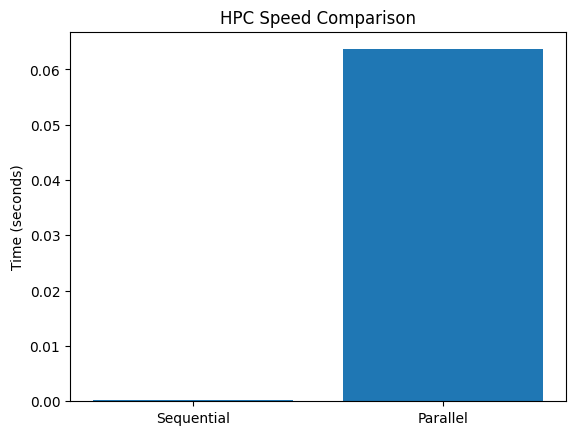

In [5]:
import multiprocessing as mp
import time
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd


def clean_chunk(chunk):
    # Example cleaning: replace NaNs with 0
    return np.nan_to_num(chunk)


def parallel_process(func, chunks, cores):
    with mp.Pool(cores) as pool:
        results = pool.map(func, chunks)
    return results


if __name__ == "__main__":

    mp.freeze_support()

    # Create a dummy data/raw.csv for testing if it doesn't exist
    if not os.path.exists('data'):
        os.makedirs('data')

    if not os.path.exists('data/raw.csv'):
        dummy_data = {
            'col1': [1, 2, np.nan, 4, 5],
            'col2': [6, 7, 8, np.nan, 10],
            'col3': [11, 12, 13, 14, 15]
        }
        dummy_df = pd.DataFrame(dummy_data)
        dummy_df.to_csv('data/raw.csv', index=False)
        print("Dummy 'data/raw.csv' created.")

    print("Loading dataset...")
    df = pd.read_csv("data/raw.csv")

    cores = 4
    print(f"Using {cores} CPU cores")

    # Use only numeric data for HPC processing
    numeric_df = df.select_dtypes(include="number")
    data_array = numeric_df.values

    # ---------- Parallel ----------
    print("Starting PARALLEL processing...")
    start = time.time()

    chunks = np.array_split(data_array, cores)
    cleaned_chunks = parallel_process(clean_chunk, chunks, cores)
    cleaned_array = np.vstack(cleaned_chunks)

    parallel_time = time.time() - start

    # ---------- Sequential ----------
    print("Starting SEQUENTIAL processing...")
    start = time.time()

    clean_chunk(data_array)

    sequential_time = time.time() - start

    # ---------- Results ----------
    print("\n===== RESULTS =====")
    print("Sequential time:", sequential_time)
    print("Parallel time:", parallel_time)

    # ---------- Chart ----------
    plt.figure()
    plt.bar(["Sequential", "Parallel"], [sequential_time, parallel_time])
    plt.ylabel("Time (seconds)")
    plt.title("HPC Speed Comparison")
    plt.savefig("data/speedup_chart.png")

    print("Done.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# New Section